# Chapter 6: Decision Trees - Interactive Tutorial

## Overview

Decision Trees are versatile Machine Learning algorithms capable of performing:
- **Classification** (predicting categories)
- **Regression** (predicting continuous values)
- **Multioutput tasks**

They are powerful, intuitive, and serve as fundamental components of Random Forests. In this notebook, we'll explore:

1. Training and visualizing Decision Trees
2. Making predictions and estimating probabilities
3. The CART algorithm and impurity measures
4. Regularization techniques
5. Regression with Decision Trees
6. Limitations and practical exercises

## 1. Import Required Libraries

First, let's import all the necessary libraries we'll use throughout this tutorial.

In [2]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Scikit-learn modules
from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# For statistical operations
from scipy import stats

# For better visualizations
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Prepare the Iris Dataset

The Iris dataset is a classic dataset containing measurements of 150 iris flowers from three different species:
- **Setosa**
- **Versicolor**
- **Virginica**

Each flower has 4 features:
1. Sepal length (cm)
2. Sepal width (cm)
3. Petal length (cm)
4. Petal width (cm)

For this tutorial, we'll use only the **petal length and width** (features 2 and 3) so we can visualize the decision boundaries in 2D.

In [3]:
# Load the Iris dataset
iris = load_iris()

# Use only petal length and width (columns 2 and 3)
X = iris.data[:, 2:]  # Features: petal length and width
y = iris.target        # Target: species (0=setosa, 1=versicolor, 2=virginica)

# Display dataset information
print("Dataset shape:", X.shape)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("Feature names:", iris.feature_names[2:])
print("Target classes:", iris.target_names)
print("\nFirst 5 samples:")
print(X[:5])
print("\nFirst 5 targets:")
print(y[:5])

Dataset shape: (150, 2)
Number of samples: 150
Number of features: 2
Feature names: ['petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

First 5 samples:
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]

First 5 targets:
[0 0 0 0 0]


## 3. Train a Basic Decision Tree Classifier

Now let's create and train a Decision Tree classifier with `max_depth=2`. This means the tree will have at most 2 levels of splits.

In [4]:
# Create a Decision Tree Classifier
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)

# Train the model
tree_clf.fit(X, y)

# Display model information
print("Decision Tree Classifier trained successfully!")
print(f"Tree depth: {tree_clf.get_depth()}")
print(f"Number of leaves: {tree_clf.get_n_leaves()}")
print(f"Training accuracy: {tree_clf.score(X, y):.4f}")

Decision Tree Classifier trained successfully!
Tree depth: 2
Number of leaves: 3
Training accuracy: 0.9600


## 4. Visualize the Decision Tree

Let's visualize our trained Decision Tree to understand how it makes decisions. We'll use matplotlib's `plot_tree` function for an easy visualization.

Each node shows:
- **samples**: Number of training instances at this node
- **value**: Distribution of instances across classes [setosa, versicolor, virginica]
- **gini**: Gini impurity (0 = pure node, all instances of same class)
- **class**: The predicted class for instances reaching this node

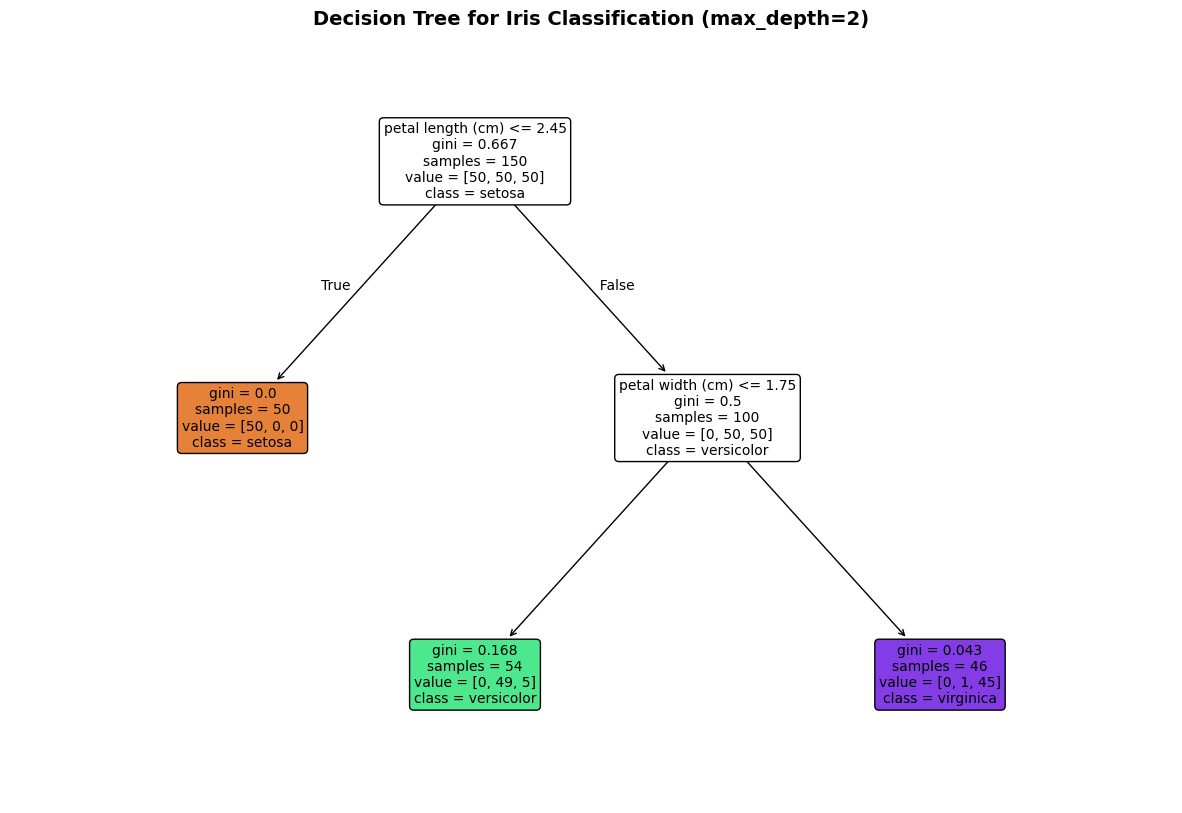

In [5]:
# Visualize the Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(tree_clf, 
          feature_names=iris.feature_names[2:],
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Iris Classification (max_depth=2)", fontsize=14, fontweight='bold')
plt.show()

## 5. Understanding Node Attributes and Gini Impurity

### What is Gini Impurity?

Gini impurity measures how "mixed" the classes are in a node. It's calculated using the formula:

$$G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$$

Where $p_{i,k}$ is the ratio of class $k$ instances in the $i^{th}$ node.

- **Gini = 0**: Pure node (all instances belong to one class)
- **Gini close to 1**: Very mixed node (instances spread evenly across classes)

Let's calculate Gini impurity manually for a sample node.

In [6]:
# Manual calculation of Gini impurity
# Example: depth-2 left node with 0 setosa, 49 versicolor, and 5 virginica

def calculate_gini(class_counts):
    """
    Calculate Gini impurity for a node.
    
    Args:
        class_counts: list of instance counts for each class
    
    Returns:
        Gini impurity value
    """
    total = sum(class_counts)
    if total == 0:
        return 0
    
    gini = 1.0
    for count in class_counts:
        p = count / total
        gini -= p ** 2
    
    return gini

# Example from the tree: left child at depth 2
class_counts = [0, 49, 5]  # [setosa, versicolor, virginica]
gini_value = calculate_gini(class_counts)

print(f"Class distribution: {class_counts}")
print(f"Total samples: {sum(class_counts)}")
print(f"Class proportions: {[c/sum(class_counts) for c in class_counts]}")
print(f"Calculated Gini impurity: {gini_value:.6f}")
print(f"Expected value: ~0.168")

# Let's also calculate for the root node
root_counts = [50, 50, 50]  # Equal distribution
root_gini = calculate_gini(root_counts)
print(f"\nRoot node (equal distribution):")
print(f"Class distribution: {root_counts}")
print(f"Gini impurity: {root_gini:.6f}")

Class distribution: [0, 49, 5]
Total samples: 54
Class proportions: [0.0, 0.9074074074074074, 0.09259259259259259]
Calculated Gini impurity: 0.168038
Expected value: ~0.168

Root node (equal distribution):
Class distribution: [50, 50, 50]
Gini impurity: 0.666667


## 6. Making Predictions with Decision Trees

Decision Trees make predictions by traversing from the root node to a leaf node based on feature values. Let's see how this works with some example predictions.

In [7]:
# Make predictions for sample instances
test_samples = [
    [2.0, 0.5],   # Small petals - likely Setosa
    [5.0, 1.5],   # Medium petals - likely Versicolor
    [6.5, 2.3]    # Large petals - likely Virginica
]

print("Making predictions for test samples:\n")
for i, sample in enumerate(test_samples):
    prediction = tree_clf.predict([sample])[0]
    class_name = iris.target_names[prediction]
    print(f"Sample {i+1}: Petal length={sample[0]} cm, Petal width={sample[1]} cm")
    print(f"  Predicted class: {class_name} (class {prediction})")
    print()

# Show the decision path for one sample
sample = [[5.0, 1.5]]
prediction = tree_clf.predict(sample)[0]
print(f"\nDecision path for sample {sample[0]}:")
print(f"1. Root node: Check if petal length <= 2.45 cm")
print(f"   → {sample[0][0]} > 2.45, go RIGHT")
print(f"2. Right child: Check if petal width <= 1.75 cm")
print(f"   → {sample[0][1]} <= 1.75, go LEFT")
print(f"3. Leaf node: Predict {iris.target_names[prediction]}")

Making predictions for test samples:

Sample 1: Petal length=2.0 cm, Petal width=0.5 cm
  Predicted class: setosa (class 0)

Sample 2: Petal length=5.0 cm, Petal width=1.5 cm
  Predicted class: versicolor (class 1)

Sample 3: Petal length=6.5 cm, Petal width=2.3 cm
  Predicted class: virginica (class 2)


Decision path for sample [5.0, 1.5]:
1. Root node: Check if petal length <= 2.45 cm
   → 5.0 > 2.45, go RIGHT
2. Right child: Check if petal width <= 1.75 cm
   → 1.5 <= 1.75, go LEFT
3. Leaf node: Predict versicolor


## 7. Estimating Class Probabilities

Decision Trees estimate probabilities by returning the ratio of training instances of each class in the leaf node. Let's see this in action.

In [8]:
# Estimate class probabilities
test_samples = [
    [5.0, 1.5],   # Medium petals
    [2.0, 0.5],   # Small petals
    [6.5, 2.3]    # Large petals
]

print("Class probability estimates:\n")
for sample in test_samples:
    proba = tree_clf.predict_proba([sample])[0]
    prediction = tree_clf.predict([sample])[0]
    
    print(f"Sample: Petal length={sample[0]} cm, Petal width={sample[1]} cm")
    print(f"  Probabilities:")
    for i, class_name in enumerate(iris.target_names):
        print(f"    {class_name}: {proba[i]:.2%}")
    print(f"  Predicted class: {iris.target_names[prediction]}")
    print()

# Explain the first sample
print("Explanation for sample [5.0, 1.5]:")
print("This sample reaches a leaf node with:")
print("  - 0 Setosa instances (0/54 = 0.00%)")
print("  - 49 Versicolor instances (49/54 = 90.74%)")
print("  - 5 Virginica instances (5/54 = 9.26%)")
print("The tree predicts Versicolor with 90.74% confidence.")

Class probability estimates:

Sample: Petal length=5.0 cm, Petal width=1.5 cm
  Probabilities:
    setosa: 0.00%
    versicolor: 90.74%
    virginica: 9.26%
  Predicted class: versicolor

Sample: Petal length=2.0 cm, Petal width=0.5 cm
  Probabilities:
    setosa: 100.00%
    versicolor: 0.00%
    virginica: 0.00%
  Predicted class: setosa

Sample: Petal length=6.5 cm, Petal width=2.3 cm
  Probabilities:
    setosa: 0.00%
    versicolor: 2.17%
    virginica: 97.83%
  Predicted class: virginica

Explanation for sample [5.0, 1.5]:
This sample reaches a leaf node with:
  - 0 Setosa instances (0/54 = 0.00%)
  - 49 Versicolor instances (49/54 = 90.74%)
  - 5 Virginica instances (5/54 = 9.26%)
The tree predicts Versicolor with 90.74% confidence.


## 8. Exploring Decision Boundaries

Let's visualize the decision boundaries created by the Decision Tree on the 2D feature space. This helps us understand how the tree partitions the input space into rectangular regions.

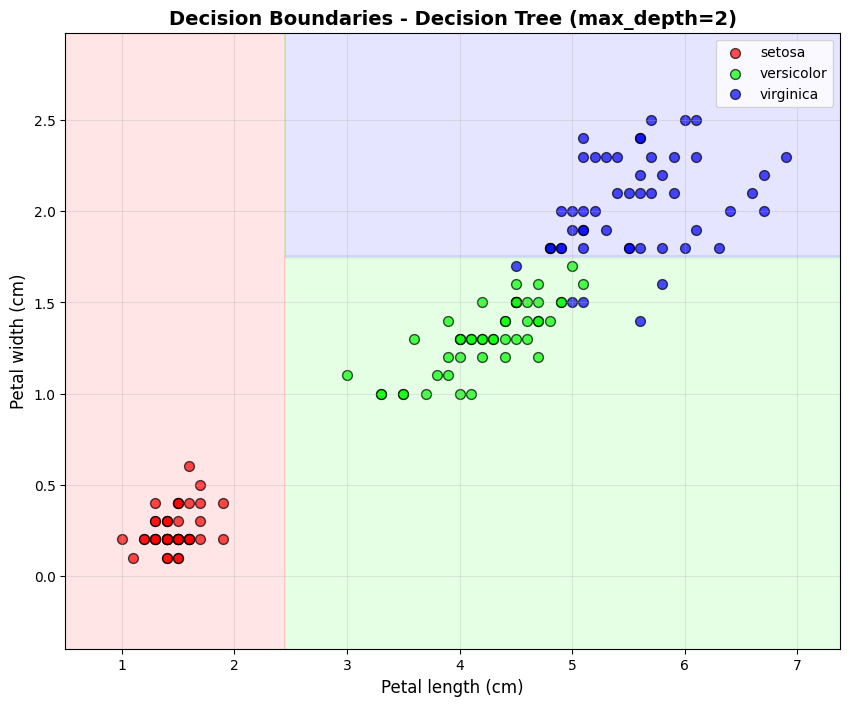

In [9]:
# Function to plot decision boundaries
def plot_decision_boundary(clf, X, y, title="Decision Boundary"):
    # Define bounds
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Create mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict for each point in mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    
    # Plot decision boundary
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF0000', '#00FF00', '#0000FF']
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    
    # Plot training points
    for i, color in enumerate(cmap_bold):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                   edgecolor='black', s=50, alpha=0.7)
    
    plt.xlabel('Petal length (cm)', fontsize=12)
    plt.ylabel('Petal width (cm)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot decision boundaries
plot_decision_boundary(tree_clf, X, y, "Decision Boundaries - Decision Tree (max_depth=2)")

## 9. Comparing Gini Impurity vs Entropy

Decision Trees can use two different impurity measures: **Gini impurity** (default) or **Entropy**. Let's compare them.

### Entropy Formula:

$$H_i = -\sum_{k=1, p_{i,k} \neq 0}^{n} p_{i,k}\log_2(p_{i,k})$$

Where $p_{i,k}$ is the ratio of class $k$ instances in node $i$.

In [10]:
# Calculate entropy manually
def calculate_entropy(class_counts):
    """
    Calculate entropy for a node.
    
    Args:
        class_counts: list of instance counts for each class
    
    Returns:
        Entropy value
    """
    total = sum(class_counts)
    if total == 0:
        return 0
    
    entropy = 0.0
    for count in class_counts:
        if count > 0:
            p = count / total
            entropy -= p * np.log2(p)
    
    return entropy

# Example: depth-2 left node with 0, 49, and 5 instances
class_counts = [0, 49, 5]
entropy_value = calculate_entropy(class_counts)
gini_value = calculate_gini(class_counts)

print("Comparison of Gini vs Entropy for the same node:")
print(f"Class distribution: {class_counts}")
print(f"Gini impurity: {gini_value:.6f}")
print(f"Entropy: {entropy_value:.6f}")
print(f"Expected entropy: ~0.445")

# Train a tree with entropy criterion
tree_clf_entropy = DecisionTreeClassifier(max_depth=2, criterion='entropy', random_state=42)
tree_clf_entropy.fit(X, y)

print(f"\nTree with Gini - Training accuracy: {tree_clf.score(X, y):.4f}")
print(f"Tree with Entropy - Training accuracy: {tree_clf_entropy.score(X, y):.4f}")
print("\nNote: Both criteria usually produce similar results.")

Comparison of Gini vs Entropy for the same node:
Class distribution: [0, 49, 5]
Gini impurity: 0.168038
Entropy: 0.445065
Expected entropy: ~0.445

Tree with Gini - Training accuracy: 0.9600
Tree with Entropy - Training accuracy: 0.9600

Note: Both criteria usually produce similar results.


## 10. Decision Tree Regression

Decision Trees can also perform **regression** tasks by predicting continuous values instead of classes. Let's create a simple regression example.

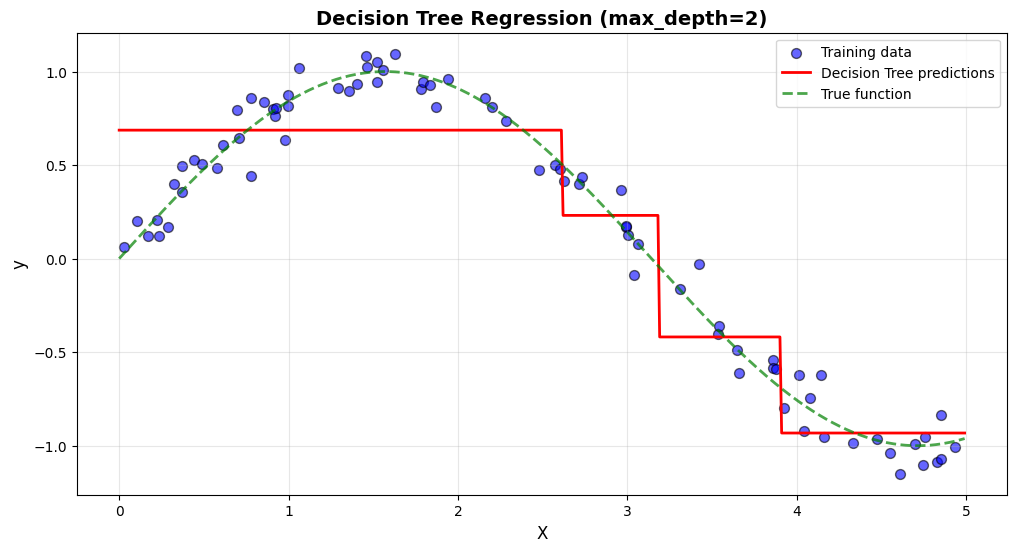

Number of leaf nodes: 4
Note: Predictions are constant within each region (rectangular partitions)


In [11]:
# Create a synthetic regression dataset
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.randn(80) * 0.1

# Train a Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_reg, y_reg)

# Make predictions
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = tree_reg.predict(X_test)

# Visualize
plt.figure(figsize=(12, 6))

# Plot the training data
plt.scatter(X_reg, y_reg, c='blue', s=50, alpha=0.6, label='Training data', edgecolor='black')

# Plot predictions
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Decision Tree predictions')

# Plot the true function
y_true = np.sin(X_test).ravel()
plt.plot(X_test, y_true, color='green', linewidth=2, linestyle='--', label='True function', alpha=0.7)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Decision Tree Regression (max_depth=2)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Number of leaf nodes: {tree_reg.get_n_leaves()}")
print("Note: Predictions are constant within each region (rectangular partitions)")

## 11. Demonstrating Overfitting Without Regularization

Without regularization, Decision Trees can easily overfit the training data. Let's see this in action by comparing a regularized tree with an unrestricted one.

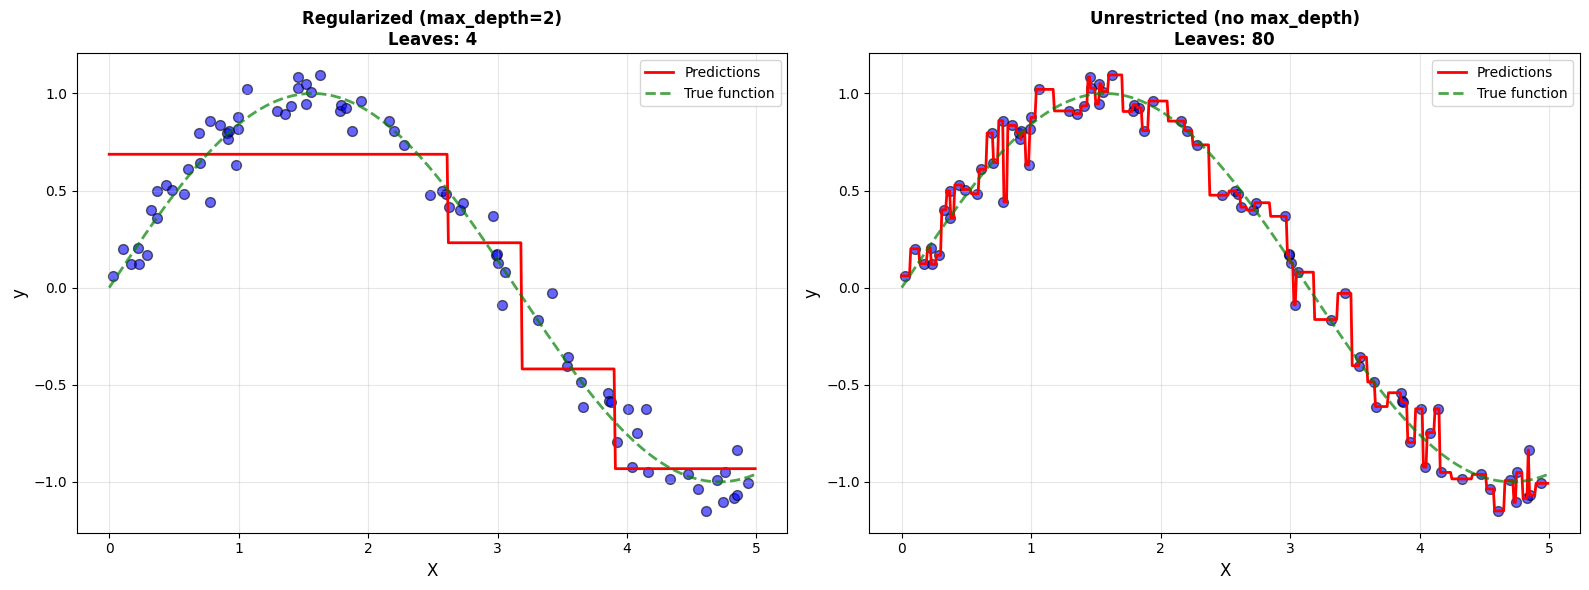

Regularized tree:
  - Depth: 2
  - Leaves: 4

Unrestricted tree:
  - Depth: 12
  - Leaves: 80

The unrestricted tree clearly overfits the training data!


In [12]:
# Train two regressors: one regularized, one unrestricted
tree_reg_regularized = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg_unrestricted = DecisionTreeRegressor(random_state=42)

tree_reg_regularized.fit(X_reg, y_reg)
tree_reg_unrestricted.fit(X_reg, y_reg)

# Make predictions
y_pred_reg = tree_reg_regularized.predict(X_test)
y_pred_unreg = tree_reg_unrestricted.predict(X_test)

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regularized tree
axes[0].scatter(X_reg, y_reg, c='blue', s=50, alpha=0.6, edgecolor='black')
axes[0].plot(X_test, y_pred_reg, color='red', linewidth=2, label='Predictions')
axes[0].plot(X_test, y_true, color='green', linewidth=2, linestyle='--', label='True function', alpha=0.7)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title(f'Regularized (max_depth=2)\nLeaves: {tree_reg_regularized.get_n_leaves()}', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Unrestricted tree
axes[1].scatter(X_reg, y_reg, c='blue', s=50, alpha=0.6, edgecolor='black')
axes[1].plot(X_test, y_pred_unreg, color='red', linewidth=2, label='Predictions')
axes[1].plot(X_test, y_true, color='green', linewidth=2, linestyle='--', label='True function', alpha=0.7)
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title(f'Unrestricted (no max_depth)\nLeaves: {tree_reg_unrestricted.get_n_leaves()}', 
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Regularized tree:")
print(f"  - Depth: {tree_reg_regularized.get_depth()}")
print(f"  - Leaves: {tree_reg_regularized.get_n_leaves()}")
print(f"\nUnrestricted tree:")
print(f"  - Depth: {tree_reg_unrestricted.get_depth()}")
print(f"  - Leaves: {tree_reg_unrestricted.get_n_leaves()}")
print(f"\nThe unrestricted tree clearly overfits the training data!")

## 12. Applying Regularization Hyperparameters

Decision Trees have several regularization hyperparameters to prevent overfitting:

- **max_depth**: Maximum depth of the tree
- **min_samples_split**: Minimum samples required to split a node
- **min_samples_leaf**: Minimum samples required in a leaf node
- **max_leaf_nodes**: Maximum number of leaf nodes

Let's experiment with these parameters.

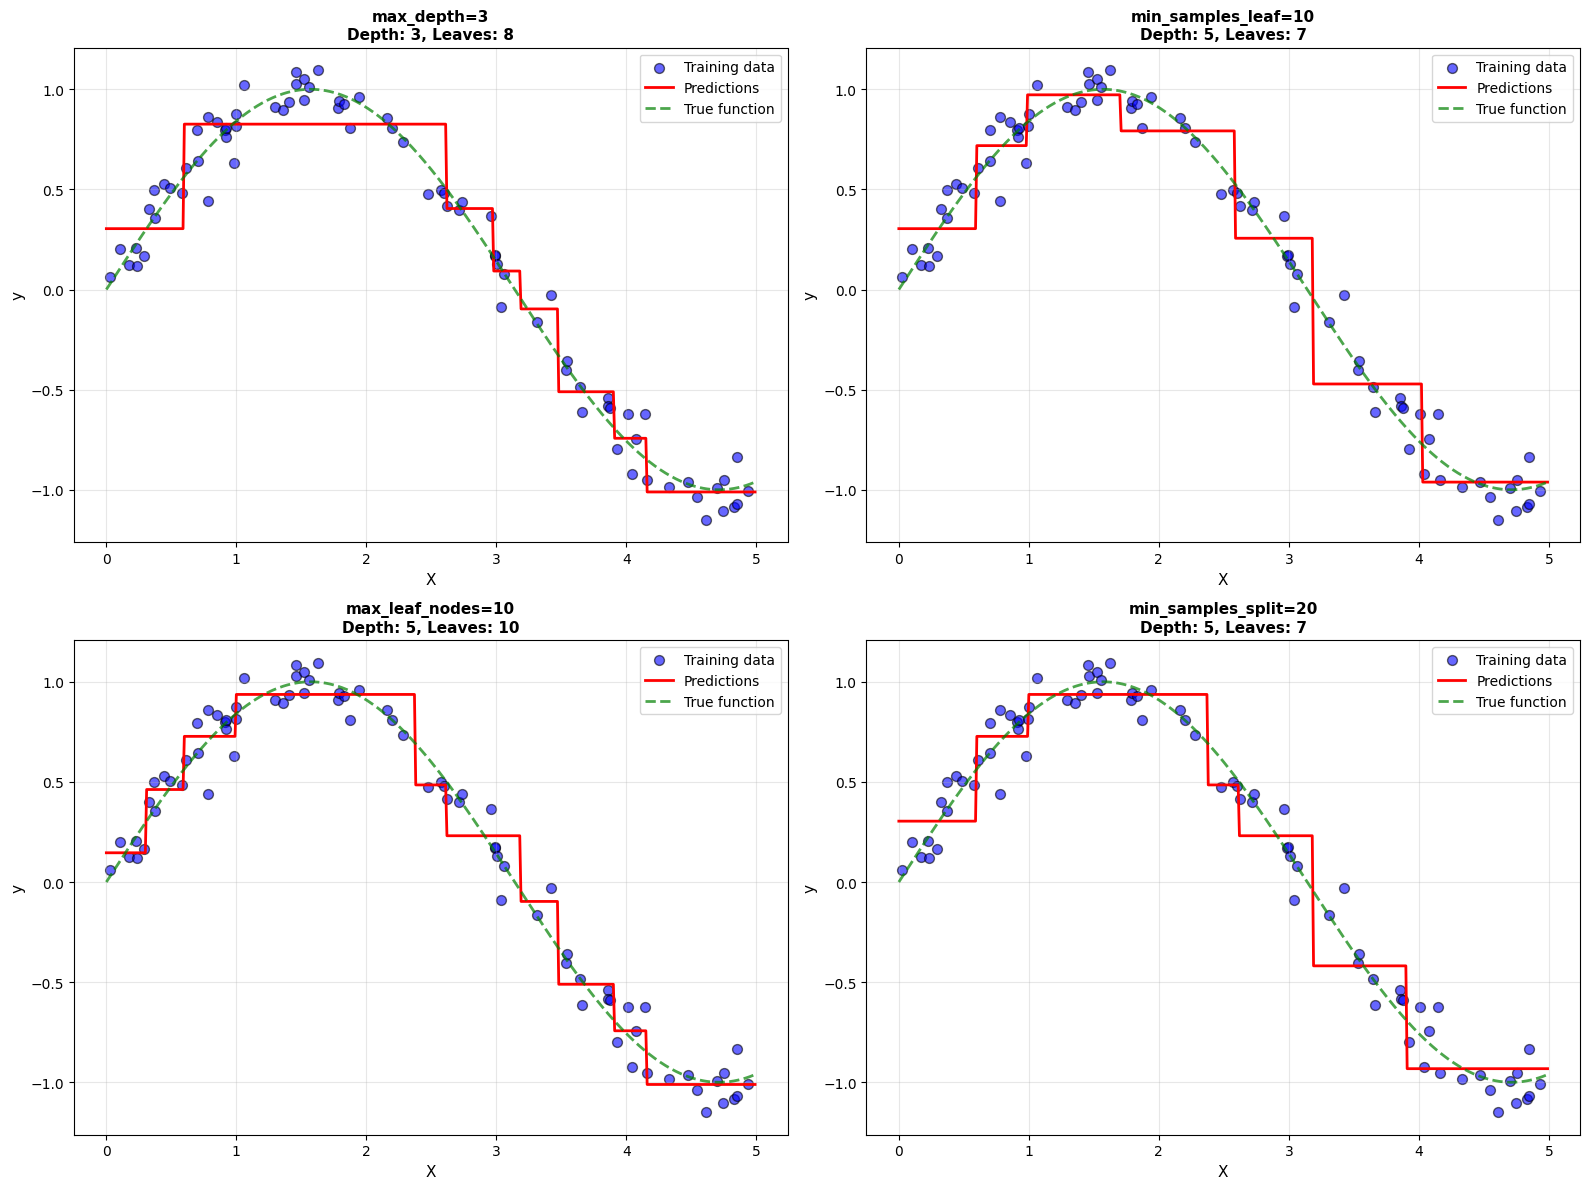

Summary of regularization effects:
- Smaller max_depth → simpler tree, fewer leaves
- Larger min_samples_leaf → more samples per leaf, fewer leaves
- Smaller max_leaf_nodes → directly limits tree complexity
- Larger min_samples_split → harder to split, fewer internal nodes


In [13]:
# Compare different regularization strategies
configs = [
    {'max_depth': 3, 'name': 'max_depth=3'},
    {'min_samples_leaf': 10, 'name': 'min_samples_leaf=10'},
    {'max_leaf_nodes': 10, 'name': 'max_leaf_nodes=10'},
    {'min_samples_split': 20, 'name': 'min_samples_split=20'}
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, config in enumerate(configs):
    # Create config dict without name
    params = {k: v for k, v in config.items() if k != 'name'}
    params['random_state'] = 42
    
    # Train regressor
    tree = DecisionTreeRegressor(**params)
    tree.fit(X_reg, y_reg)
    
    # Make predictions
    y_pred = tree.predict(X_test)
    
    # Plot
    axes[i].scatter(X_reg, y_reg, c='blue', s=50, alpha=0.6, edgecolor='black', label='Training data')
    axes[i].plot(X_test, y_pred, color='red', linewidth=2, label='Predictions')
    axes[i].plot(X_test, y_true, color='green', linewidth=2, linestyle='--', label='True function', alpha=0.7)
    axes[i].set_xlabel('X', fontsize=11)
    axes[i].set_ylabel('y', fontsize=11)
    axes[i].set_title(f'{config["name"]}\nDepth: {tree.get_depth()}, Leaves: {tree.get_n_leaves()}', 
                      fontsize=11, fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary of regularization effects:")
print("- Smaller max_depth → simpler tree, fewer leaves")
print("- Larger min_samples_leaf → more samples per leaf, fewer leaves")
print("- Smaller max_leaf_nodes → directly limits tree complexity")
print("- Larger min_samples_split → harder to split, fewer internal nodes")

## 13. Sensitivity to Data Rotation (PCA Example)

Decision Trees prefer **orthogonal decision boundaries** (perpendicular to axes). When data is rotated, trees may struggle. Let's demonstrate this using PCA (Principal Component Analysis).

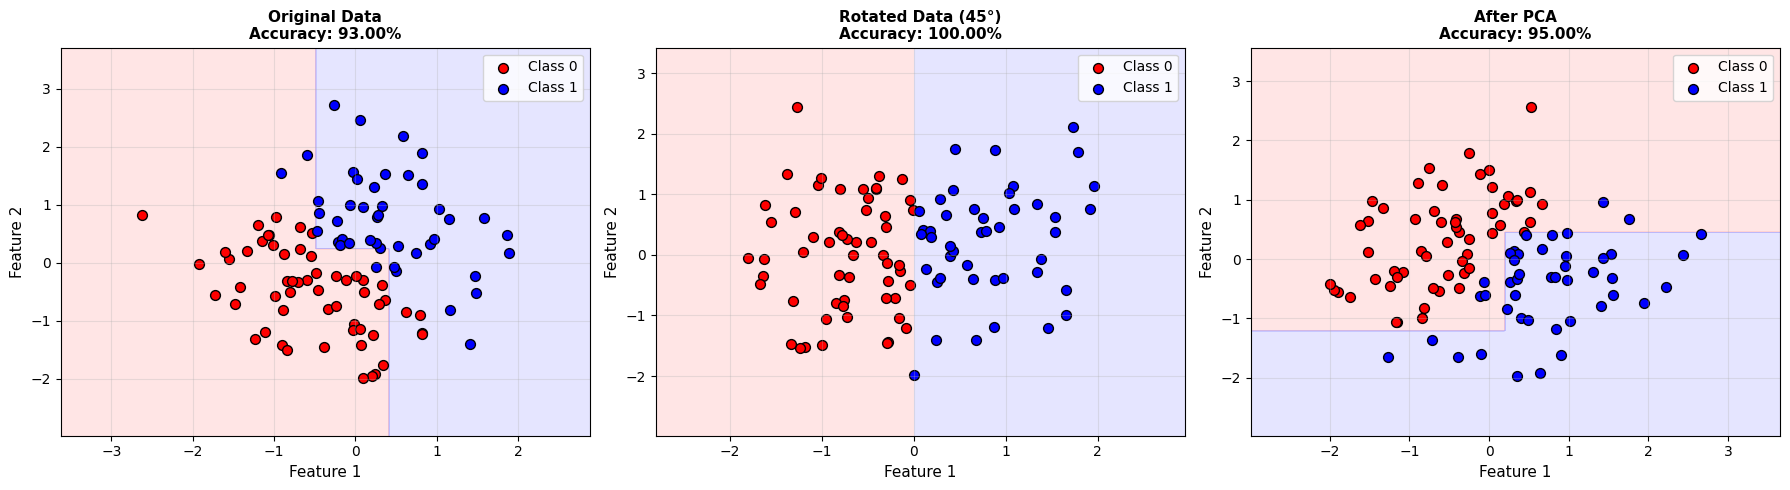

Observation:
- Original data: Tree fits well with axis-aligned boundaries
- Rotated data: Tree struggles with diagonal boundary
- After PCA: Realigns data with axes, improving fit


In [14]:
# Create a simple 2D dataset
np.random.seed(42)
X_simple = np.random.randn(100, 2)
y_simple = (X_simple[:, 0] + X_simple[:, 1] > 0).astype(int)

# Rotate the data by 45 degrees
angle = np.pi / 4  # 45 degrees
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])
X_rotated = X_simple.dot(rotation_matrix)

# Train trees on both datasets
tree_simple = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_rotated = DecisionTreeClassifier(max_depth=2, random_state=42)

tree_simple.fit(X_simple, y_simple)
tree_rotated.fit(X_rotated, y_simple)

# Apply PCA to align data with axes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rotated)
tree_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_pca.fit(X_pca, y_simple)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (X_simple, "Original Data", tree_simple),
    (X_rotated, "Rotated Data (45°)", tree_rotated),
    (X_pca, "After PCA", tree_pca)
]

for ax, (X_data, title, tree) in zip(axes, datasets):
    # Plot decision boundary
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    ax.scatter(X_data[y_simple==0, 0], X_data[y_simple==0, 1], c='red', 
              edgecolor='black', s=50, label='Class 0')
    ax.scatter(X_data[y_simple==1, 0], X_data[y_simple==1, 1], c='blue', 
              edgecolor='black', s=50, label='Class 1')
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.set_title(f'{title}\nAccuracy: {tree.score(X_data, y_simple):.2%}', 
                fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation:")
print("- Original data: Tree fits well with axis-aligned boundaries")
print("- Rotated data: Tree struggles with diagonal boundary")
print("- After PCA: Realigns data with axes, improving fit")

## 14. Sensitivity to Small Data Variations

Decision Trees are very sensitive to small changes in the training data. Removing just one instance can result in a completely different tree. Let's demonstrate this instability.

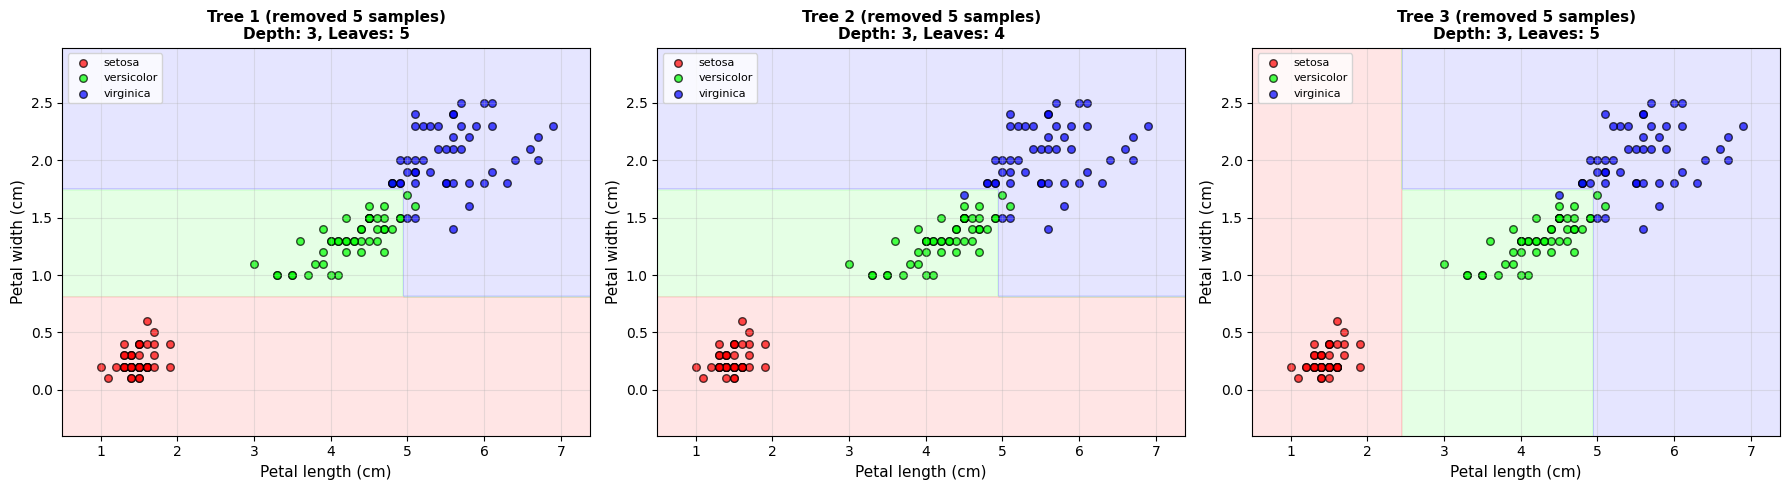

Observation:
Each tree is trained on a slightly different subset (removed 5 random samples)
Notice how the decision boundaries and tree structures can vary significantly!

Solution: Use Random Forests (next chapter) to average predictions from many trees.


In [15]:
# Train multiple trees on slightly different datasets
np.random.seed(42)
n_trees = 3
n_remove = 5  # Number of instances to remove

fig, axes = plt.subplots(1, n_trees, figsize=(18, 5))

for i in range(n_trees):
    # Create a slightly modified dataset by removing random instances
    indices = np.random.choice(len(X), len(X) - n_remove, replace=False)
    X_subset = X[indices]
    y_subset = y[indices]
    
    # Train a tree
    tree = DecisionTreeClassifier(max_depth=3, random_state=i)
    tree.fit(X_subset, y_subset)
    
    # Plot decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF0000', '#00FF00', '#0000FF']
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    
    for j, color in enumerate(cmap_bold):
        idx = np.where(y_subset == j)
        axes[i].scatter(X_subset[idx, 0], X_subset[idx, 1], c=color, 
                       label=iris.target_names[j], edgecolor='black', s=30, alpha=0.7)
    
    axes[i].set_xlabel('Petal length (cm)', fontsize=11)
    axes[i].set_ylabel('Petal width (cm)', fontsize=11)
    axes[i].set_title(f'Tree {i+1} (removed {n_remove} samples)\n'
                     f'Depth: {tree.get_depth()}, Leaves: {tree.get_n_leaves()}', 
                     fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation:")
print("Each tree is trained on a slightly different subset (removed 5 random samples)")
print("Notice how the decision boundaries and tree structures can vary significantly!")
print("\nSolution: Use Random Forests (next chapter) to average predictions from many trees.")

## 15. Exercise 7: Moons Dataset with Grid Search

Now let's work on a practical exercise! We'll:
1. Generate a moons dataset (non-linearly separable data)
2. Split into train/test sets
3. Use Grid Search with Cross-Validation to find optimal hyperparameters
4. Evaluate the final model

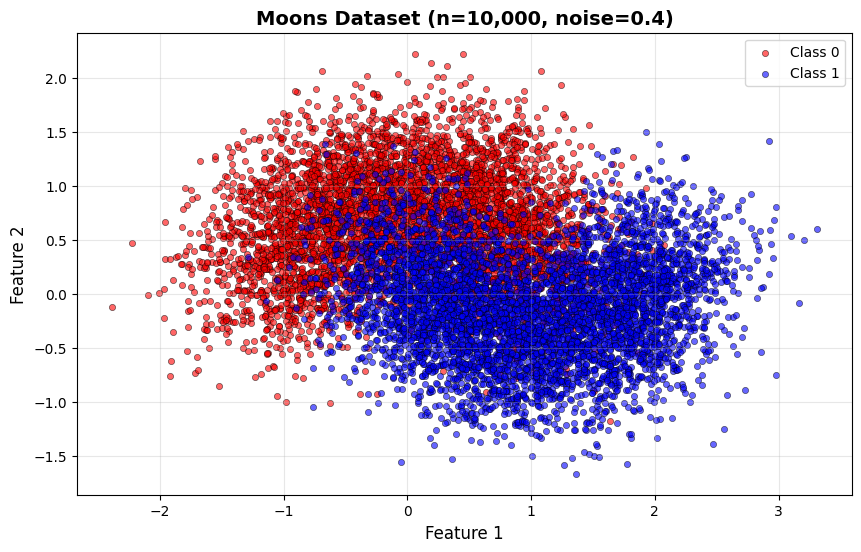

Dataset shape: (10000, 2)
Class distribution: [5000 5000]


In [16]:
# Step 1: Generate moons dataset
X_moons, y_moons = make_moons(n_samples=10000, noise=0.4, random_state=42)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], 
           c='red', s=20, alpha=0.6, edgecolor='black', linewidth=0.5, label='Class 0')
plt.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], 
           c='blue', s=20, alpha=0.6, edgecolor='black', linewidth=0.5, label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Moons Dataset (n=10,000, noise=0.4)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X_moons.shape}")
print(f"Class distribution: {np.bincount(y_moons)}")

In [17]:
# Step 2: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 8000
Test set size: 2000


In [18]:
# Step 3: Grid Search with Cross-Validation
param_grid = {
    'max_leaf_nodes': [10, 20, 30, 40, 50, 100],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

tree_clf_moons = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    tree_clf_moons, 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print("\nGrid Search Complete!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Grid Search Complete!
Best parameters: {'max_depth': 7, 'max_leaf_nodes': 20, 'min_samples_split': 2}
Best cross-validation score: 0.8586

Grid Search Complete!
Best parameters: {'max_depth': 7, 'max_leaf_nodes': 20, 'min_samples_split': 2}
Best cross-validation score: 0.8586


Training accuracy: 0.8639
Test accuracy: 0.8700

Tree depth: 7
Number of leaves: 20


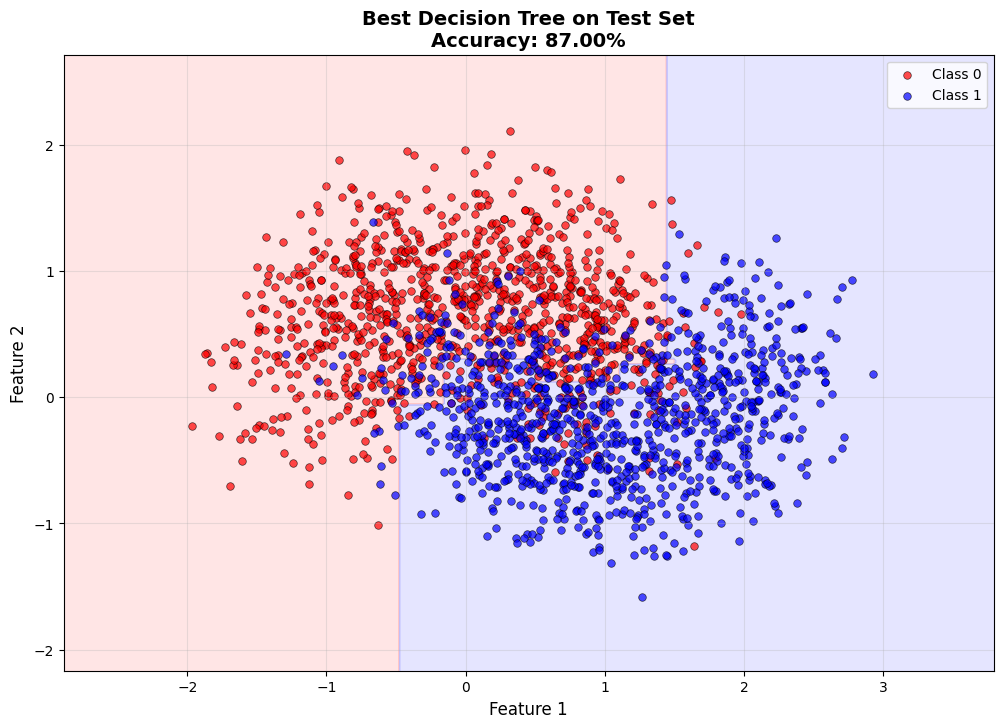

In [19]:
# Step 4: Evaluate on test set
best_tree = grid_search.best_estimator_

# Training accuracy
train_accuracy = best_tree.score(X_train, y_train)
# Test accuracy
test_accuracy = best_tree.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"\nTree depth: {best_tree.get_depth()}")
print(f"Number of leaves: {best_tree.get_n_leaves()}")

# Visualize decision boundary
plt.figure(figsize=(12, 8))

# Create mesh
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = best_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
           c='red', s=30, alpha=0.7, edgecolor='black', linewidth=0.5, label='Class 0')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
           c='blue', s=30, alpha=0.7, edgecolor='black', linewidth=0.5, label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title(f'Best Decision Tree on Test Set\nAccuracy: {test_accuracy:.2%}', 
         fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 16. Exercise 8: Building a Simple Random Forest

Now let's build a simple Random Forest from scratch! This is a preview of Chapter 7. We'll:
1. Create 1,000 subsets of the training data using `ShuffleSplit`
2. Train one Decision Tree on each subset
3. Use majority voting to make predictions
4. Compare with a single tree's performance

In [20]:
# Step 1: Generate 1,000 subsets using ShuffleSplit
n_trees = 1000
n_subset_size = 100

# ShuffleSplit creates random train/test indices
shuffle_split = ShuffleSplit(n_splits=n_trees, test_size=len(X_train)-n_subset_size, random_state=42)

print(f"Creating {n_trees} subsets of size {n_subset_size}...")
print("This may take a moment...")

Creating 1000 subsets of size 100...
This may take a moment...


In [21]:
# Step 2: Train 1,000 Decision Trees on subsets
from time import time

forest = []
start_time = time()

for i, (train_index, _) in enumerate(shuffle_split.split(X_train)):
    # Get subset
    X_subset = X_train[train_index]
    y_subset = y_train[train_index]
    
    # Train a tree with best hyperparameters from grid search
    tree = DecisionTreeClassifier(
        max_leaf_nodes=grid_search.best_params_['max_leaf_nodes'],
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        random_state=42
    )
    tree.fit(X_subset, y_subset)
    forest.append(tree)
    
    if (i + 1) % 200 == 0:
        print(f"Trained {i + 1}/{n_trees} trees...")

end_time = time()
print(f"\nTraining completed in {end_time - start_time:.2f} seconds")
print(f"Forest contains {len(forest)} trees")

Trained 200/1000 trees...
Trained 400/1000 trees...
Trained 400/1000 trees...
Trained 600/1000 trees...
Trained 600/1000 trees...
Trained 800/1000 trees...
Trained 1000/1000 trees...

Training completed in 1.23 seconds
Forest contains 1000 trees
Trained 800/1000 trees...
Trained 1000/1000 trees...

Training completed in 1.23 seconds
Forest contains 1000 trees


In [22]:
# Step 3: Evaluate individual trees on test set
print("Evaluating individual trees on test set...")

tree_accuracies = []
for tree in forest[:100]:  # Sample first 100 trees for speed
    accuracy = tree.score(X_test, y_test)
    tree_accuracies.append(accuracy)

mean_tree_accuracy = np.mean(tree_accuracies)
std_tree_accuracy = np.std(tree_accuracies)

print(f"Average individual tree accuracy: {mean_tree_accuracy:.4f} ± {std_tree_accuracy:.4f}")
print(f"Min accuracy: {min(tree_accuracies):.4f}")
print(f"Max accuracy: {max(tree_accuracies):.4f}")
print("\nAs expected, individual trees trained on smaller subsets perform worse.")

Evaluating individual trees on test set...
Average individual tree accuracy: 0.8006 ± 0.0250
Min accuracy: 0.7300
Max accuracy: 0.8500

As expected, individual trees trained on smaller subsets perform worse.


In [23]:
# Step 4: Make predictions using majority voting
print("Making predictions with majority voting...")

# Get predictions from all trees
y_pred_forest = np.zeros((len(X_test), n_trees), dtype=int)

for i, tree in enumerate(forest):
    y_pred_forest[:, i] = tree.predict(X_test)
    if (i + 1) % 200 == 0:
        print(f"Predicted with {i + 1}/{n_trees} trees...")

# Use majority voting (mode) for final predictions
y_pred_majority, _ = stats.mode(y_pred_forest, axis=1, keepdims=False)

# Calculate accuracy
forest_accuracy = accuracy_score(y_test, y_pred_majority)

print(f"\n{'='*60}")
print("RESULTS COMPARISON:")
print(f"{'='*60}")
print(f"Single best tree (from grid search): {test_accuracy:.4f}")
print(f"Average individual tree (on subset):  {mean_tree_accuracy:.4f}")
print(f"Random Forest (majority voting):      {forest_accuracy:.4f}")
print(f"{'='*60}")
print(f"\nImprovement over single tree: {(forest_accuracy - test_accuracy)*100:.2f}%")
print(f"Improvement over average subset tree: {(forest_accuracy - mean_tree_accuracy)*100:.2f}%")
print("\n🎉 Congratulations! You've built a Random Forest classifier!")

Making predictions with majority voting...
Predicted with 200/1000 trees...
Predicted with 400/1000 trees...
Predicted with 400/1000 trees...
Predicted with 600/1000 trees...
Predicted with 600/1000 trees...
Predicted with 800/1000 trees...
Predicted with 1000/1000 trees...
Predicted with 800/1000 trees...
Predicted with 1000/1000 trees...

RESULTS COMPARISON:
Single best tree (from grid search): 0.8700
Average individual tree (on subset):  0.8006
Random Forest (majority voting):      0.8735

Improvement over single tree: 0.35%
Improvement over average subset tree: 7.29%

🎉 Congratulations! You've built a Random Forest classifier!

RESULTS COMPARISON:
Single best tree (from grid search): 0.8700
Average individual tree (on subset):  0.8006
Random Forest (majority voting):      0.8735

Improvement over single tree: 0.35%
Improvement over average subset tree: 7.29%

🎉 Congratulations! You've built a Random Forest classifier!


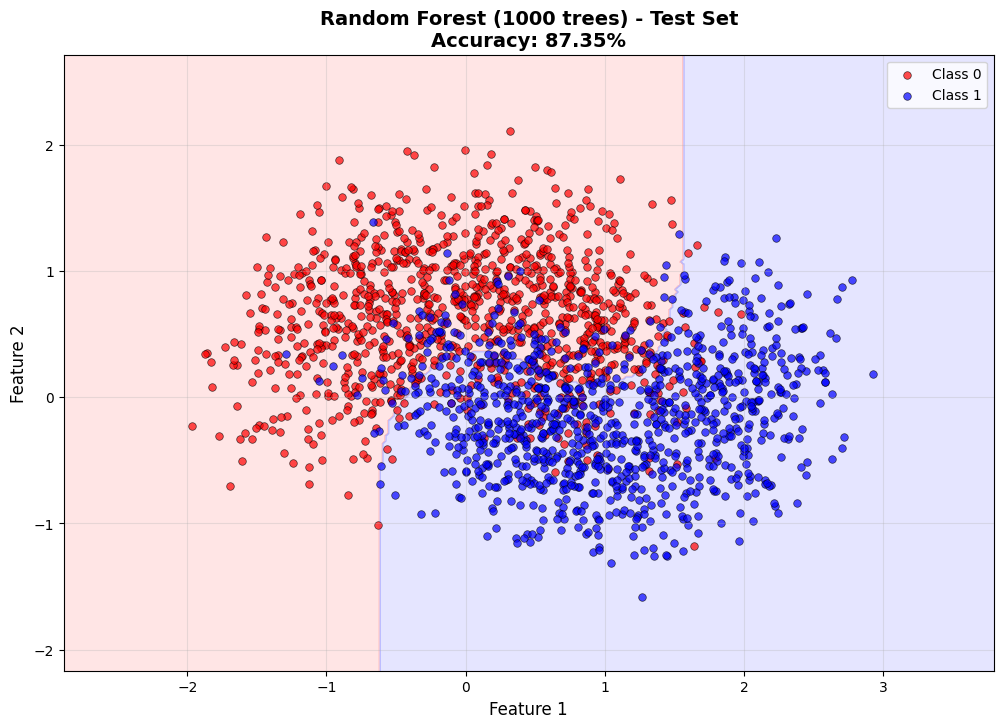

In [24]:
# Visualize Random Forest predictions
plt.figure(figsize=(12, 8))

# Create mesh for decision boundary
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions from all trees for mesh points
Z_forest = np.zeros((xx.ravel().shape[0], n_trees), dtype=int)
for i, tree in enumerate(forest):
    Z_forest[:, i] = tree.predict(np.c_[xx.ravel(), yy.ravel()])

# Majority voting
Z_majority, _ = stats.mode(Z_forest, axis=1, keepdims=False)
Z_majority = Z_majority.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z_majority, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
           c='red', s=30, alpha=0.7, edgecolor='black', linewidth=0.5, label='Class 0')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
           c='blue', s=30, alpha=0.7, edgecolor='black', linewidth=0.5, label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title(f'Random Forest (1000 trees) - Test Set\nAccuracy: {forest_accuracy:.2%}', 
         fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary and Key Takeaways

### What We Learned:

1. **Decision Trees** are versatile ML algorithms for classification and regression
   - Make predictions by traversing from root to leaf nodes
   - Use simple yes/no questions at each node
   
2. **Impurity Measures**:
   - **Gini Impurity**: $G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$ (default, faster)
   - **Entropy**: $H_i = -\sum_{k=1}^{n} p_{i,k}\log_2(p_{i,k})$ (slightly more balanced)

3. **CART Algorithm**:
   - Greedy algorithm that splits data to minimize impurity
   - Training: $O(n × m \log_2(m))$
   - Prediction: $O(\log_2(m))$ - very fast!

4. **Regularization is Essential**:
   - `max_depth`: Limit tree depth
   - `min_samples_split`: Minimum samples to split a node
   - `min_samples_leaf`: Minimum samples in leaf
   - `max_leaf_nodes`: Limit number of leaves

5. **Advantages**:
   - ✅ Easy to interpret (white box model)
   - ✅ No feature scaling needed
   - ✅ Fast predictions
   - ✅ Works for classification and regression

6. **Disadvantages**:
   - ❌ Prone to overfitting
   - ❌ Sensitive to data rotation (prefer axis-aligned boundaries)
   - ❌ Unstable with small data variations
   - ❌ Not guaranteed to find optimal tree

7. **Solution to Instability**: **Random Forests**
   - Train many trees on random subsets
   - Use majority voting for predictions
   - Significantly improves performance and stability

### Next Steps:
- Chapter 7: Random Forests and Ensemble Methods
- Explore Gradient Boosting (XGBoost, LightGBM)
- Learn about feature importance and interpretation

---

**Thank you for completing this tutorial!** 🎉